In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('smartcart_customers.csv')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

# Feature Engineering

In [9]:
df["Age"] = 2026 - df['Year_Birth']

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
# joining date of customers
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'] , dayfirst = True)

reference_date = df['Dt_Customer'].max()

df["Customer_Tenure"] = (reference_date - df['Dt_Customer']).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
#Total_spendings

df['total_spendings'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'] 
#total childrens
df['total_children'] = df['Kidhome'] + df['Teenhome']

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,total_spendings,total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure', 'total_spendings',
       'total_children'],
      dtype='object')

In [16]:
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
   "Graduation": "Graduate","Basic" : "UnderGraduate" , "2n Cycle" : "UnderGraduate",
    "Master" : "PostGraduate" , "PhD" : "PostGraduate"
})

In [17]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [18]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [19]:
# living with

df["living_with"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together" : "Partner",
    "Single" : "Alone" , "Divorced" : "Alone" , "Widow" : "Alone", "Absurd" : "Alone" , "YOLO" : "Alone"
}) 

In [20]:
df["living_with"].value_counts()

living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [21]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,total_spendings,total_children,living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


# Drop Unneccessary columns

In [83]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure', 'total_spendings',
       'total_children', 'living_with'],
      dtype='object')

In [84]:
cols = ['ID' ,'Year_Birth' ,'Marital_Status' , 'Kidhome' , 'Teenhome' , 'Dt_Customer']

spending_cols = ['MntMeatProducts' , 'MntFishProducts' , 'MntWines' ,'MntFruits' ,'MntSweetProducts' ,'MntGoldProds']


cols_to_remove = cols + spending_cols
df_cleaned = df.drop(columns = cols + spending_cols , axis = 1)

In [85]:
df_cleaned.shape

(2240, 15)

In [86]:
df.shape

(2240, 27)

# Outliers

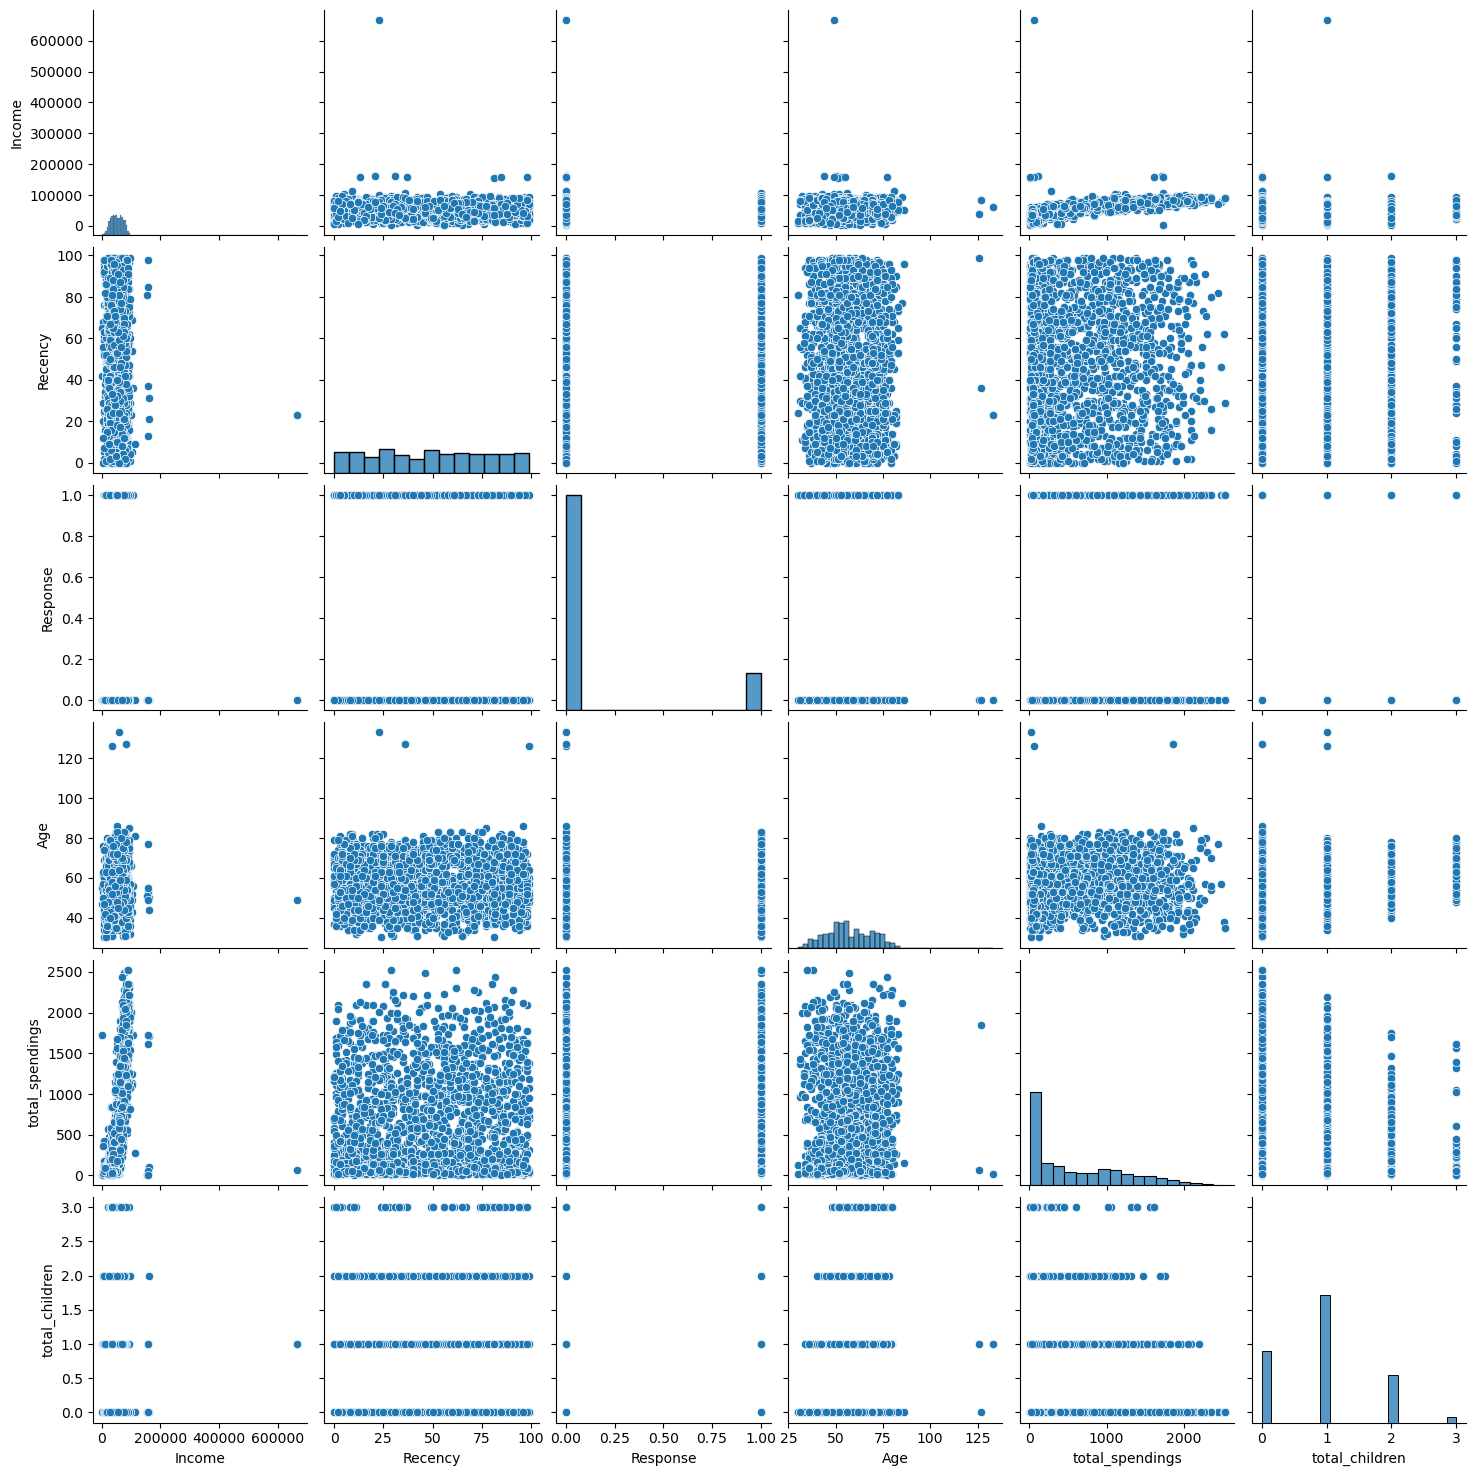

In [87]:
cols = ["Income" , "Recency" , "Response" , "Age" , "total_spendings" , "total_children"]

sns.pairplot(df_cleaned[cols])

In [88]:
#Remove Outliers

print("Data with outliers : " , len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("Data without outliers : " , len(df_cleaned))


Data with outliers :  2240
Data without outliers :  2236


# Heatmap

In [89]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

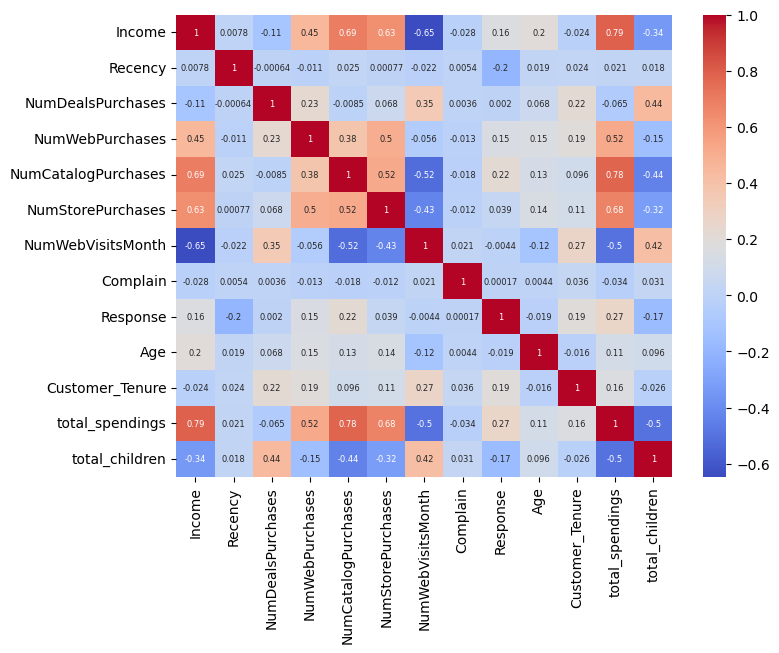

In [90]:
plt.figure(figsize = (8 , 6))

sns.heatmap(
    corr , 
    annot = True , 
    annot_kws = {"size" : 6},
    cmap = "coolwarm"
)


## Feature Encoding

In [91]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

In [92]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,total_spendings,total_children,living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [93]:
cat_cols = ['Education' , 'living_with']

encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [94]:
encoded_df = pd.DataFrame(encoded_cols.toarray() , columns = ohe.get_feature_names_out(cat_cols) , index = df_cleaned.index)

In [95]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols) , encoded_df] , axis = 1)

In [97]:
df_encoded.shape

(2236, 18)

In [98]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,total_spendings,total_children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,living_with_Alone,living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [99]:
df_cleaned.shape

(2236, 15)

## Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [100]:
X_scaled = scaler.fit_transform(df_encoded)

# Visualizing

In [101]:
X_scaled.shape

(2236, 18)

In [102]:
from sklearn.decomposition import PCA

In [103]:
pca = PCA(n_components = 3)

In [104]:
X_pca = pca.fit_transform(X_scaled)

In [105]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

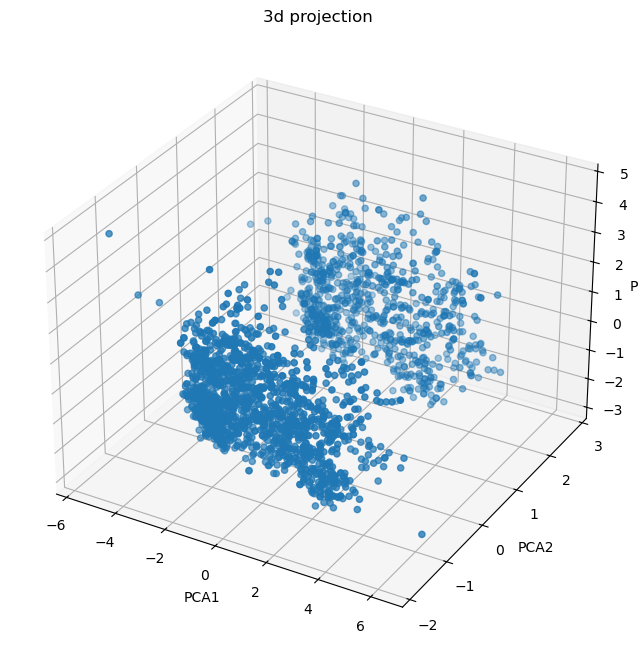

In [106]:
fig =plt.figure(figsize = (10 , 8))

ax = fig.add_subplot(111 , projection = "3d")

ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Choose k
## 1. Elbow method

In [107]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1 ,11):

    kmeans = KMeans(n_clusters = k , random_state = 42)
    labels = kmeans.fit_predict(X_pca)

    wcss_val = kmeans.inertia_
    wcss.append(wcss_val)
    
    

In [108]:
knee = KneeLocator(range(1 , 11) , wcss , curve = "convex" , direction = "decreasing")

knee.knee

np.int64(4)

# 2. Silhouette Score

In [109]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2 , 11):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    labels = kmeans.fit_predict(X_pca)

    score =  silhouette_score(X_pca , labels)

    scores.append(score)

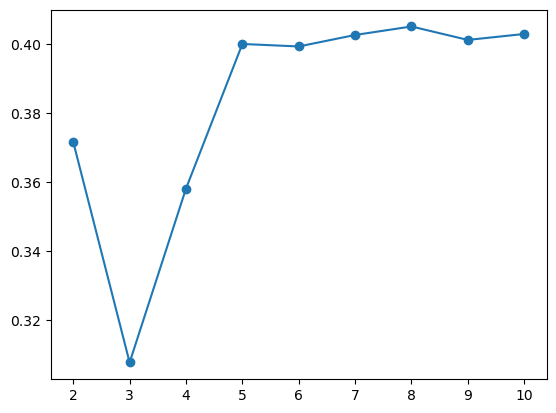

In [110]:
plt.plot(range(2 , 11) , scores , marker  = "o")

Text(0, 0.5, 'Scores')

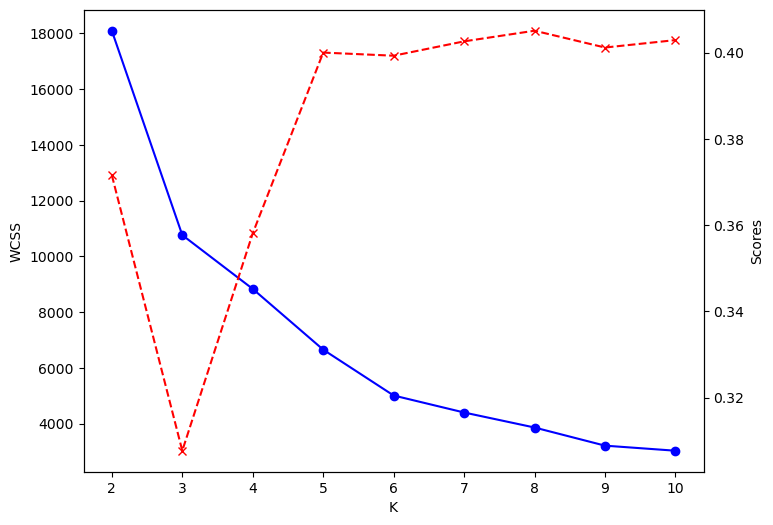

In [111]:
# combined plots

k_range = range(2 , 11)

fig , ax1 = plt.subplots(figsize = (8 , 6))
ax1.plot(k_range , wcss[:len(k_range)] , marker = "o" , color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range , scores[:len(k_range)] , marker = "x" , color = "red" , linestyle = "--")
ax2.set_ylabel("Scores")

## Clustering

In [112]:
#Best Pick = 4

kmeans = KMeans(n_clusters = 4 , random_state = 42)

labels_kmeans = kmeans.fit_predict(X_pca)

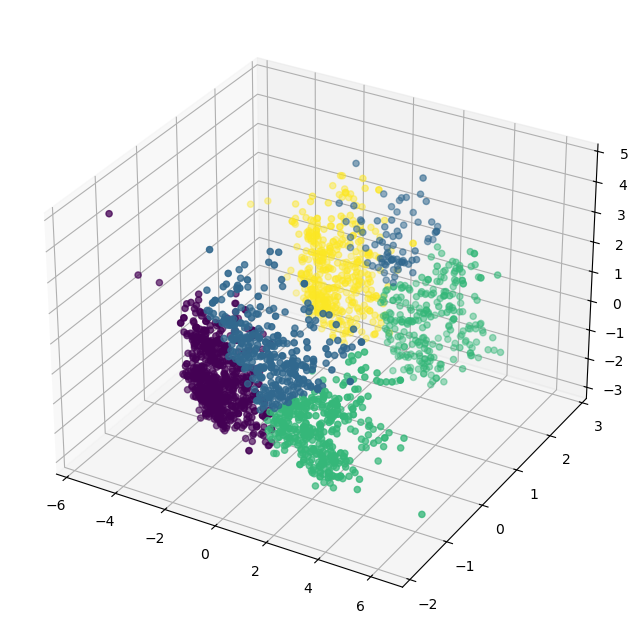

In [113]:
#plot using kmeans
fig =plt.figure(figsize = (10 , 8))

ax = fig.add_subplot(111 , projection = "3d")

ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2] , c = labels_kmeans)

In [114]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4 )
labels_agg =  agg.fit_predict(X_pca)

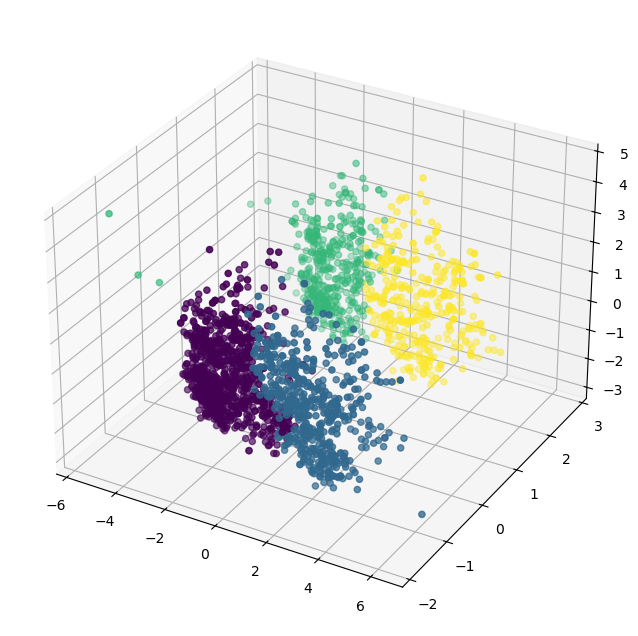

In [115]:
#plot using agglomerative
fig =plt.figure(figsize = (10 , 8))

ax = fig.add_subplot(111 , projection = "3d")

ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2] , c = labels_agg)

In [129]:
df_encoded["clusters"] = labels_agg 

In [130]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,total_spendings,total_children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,living_with_Alone,living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

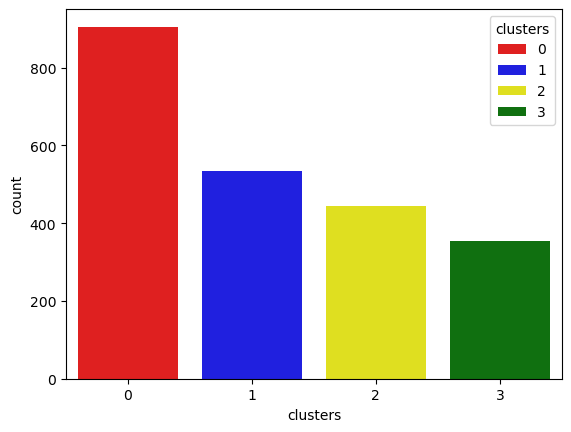

In [131]:
pal = ["red" , "blue" , "yellow" , "green"]

sns.countplot(x = df_encoded["clusters"] , palette = pal , hue = df_encoded["clusters"])

<Axes: xlabel='Income', ylabel='total_spendings'>

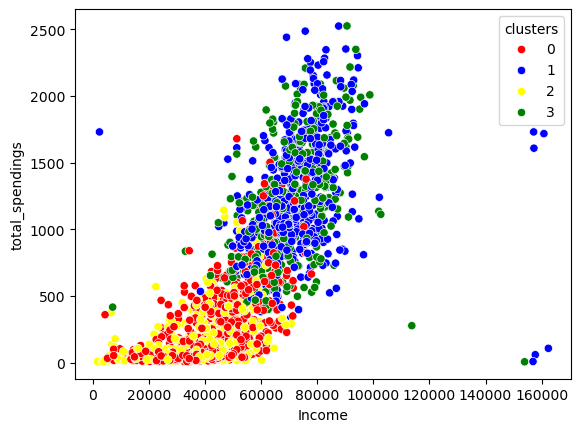

In [132]:
sns.scatterplot(x = df_encoded["Income"] , y = df_encoded["total_spendings"] , hue = df_encoded["clusters"] , palette = pal)

In [133]:
cluster_summary = df_encoded.groupby("clusters").mean()

print("Cluster Summary" , cluster_summary)

Cluster Summary                 Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure  total_spen